In [4]:
import igraph as ig 
import numpy as np
import matplotlib.pyplot as plt
from sys import stdout

from segregation_model import segregation_sim, satisfaction
from lorenzo_utils import *

G = load_graph(DATA_DIR+'climate_23.graphml')
attr_map = np.array([1 if v == 'A' else 0 for v in G.vs['group']])
nodes = nodes_all(G)
nodes_satisfaction = np.array([satisfaction(n,G.neighbors(n),G.vs['group']) for n in nodes])

In [14]:
treshold = 0.95
ei_obs = ei_index(G, attr_map)
cross_fraction_obs = 1-cross_type_fraction(G, attr_map)
satisfaction_rate_obs = nodes_satisfaction[nodes_satisfaction >= treshold].size / nodes.size
segregation_index_obs = np.mean(nodes_satisfaction)
ei_index_sim = []
cross_fraction_sim = []
satisfaction_rate_sim = []
segregation_index_sim = []
print('target simulazione: EI =', round(ei_obs,4), '   Fraction =', round(cross_fraction_obs,4), '\n')
stdout.flush()
for G_sim, statistic in segregation_sim(G,treshold, max_satisfaction=0.98):
    ei_index_sim.append(ei_index(G_sim, attr_map))
    cross_fraction_sim.append(1-cross_type_fraction(G_sim, attr_map))
    satisfaction_rate_sim.append(statistic['satisfaction_rate'])
    segregation_index_sim.append(statistic['segregation_index'])
    if statistic['i_step']:
        print(f'Segregation Model Step {statistic['i_step']}')
        print(f'Changed {statistic['nodes_changed_step']} nodes with {statistic['rewires_step']} rewires')
        trys = statistic['nodes_failures_step']+statistic['nodes_changed_step']
        # print(f'Failed for', statistic['nodes_failures_step'], 'nodes    success:', 
        #     statistic['nodes_changed_step']*100/trys if trys else 100, '%')
        print('Satisfaction:', statistic['satisfaction_rate'], '    Index:', statistic['segregation_index'])
    if not statistic['i_step']:
        print('Simulation started with:', end='')
    print('EI =', round(ei_index_sim[-1],4),
        '   Fraction =', round(cross_fraction_sim[-1],4),'\n')
    stdout.flush()

if not statistic['nodes_changed_step']:
    print('Simulation ended in a stable configuration at step', statistic['i_step'])
    print('Total failures', len(list(filter(lambda x: x>0, statistic['nodes_failures']))))
else:
    print('Simulation stopped at satisfaction rate of:', statistic['satisfaction_rate']*100, '%')

target simulazione: EI = -0.93    Fraction = 0.965 

Simulation started with: EI = -0.0592    Fraction = 0.5296 

Segregation Model Step 1
Changed 6745 nodes with 6745 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.2879    Fraction = 0.6439 

Segregation Model Step 2
Changed 4476 nodes with 4476 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.3625    Fraction = 0.6813 

Segregation Model Step 3
Changed 3791 nodes with 3791 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.4071    Fraction = 0.7035 

Segregation Model Step 4
Changed 3355 nodes with 3355 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.4434    Fraction = 0.7217 

Segregation Model Step 5
Changed 3095 nodes with 3095 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.472    Fraction = 0.736 

Segregation Model Step 6
Changed 2864 nodes with 2864 rewires
Failed for 0 nodes    success: 100.0 %
 EI = -0.4928    Fraction = 0.7464 

Segregation Model Step 7
Changed 2792 nodes with 2792 rewire

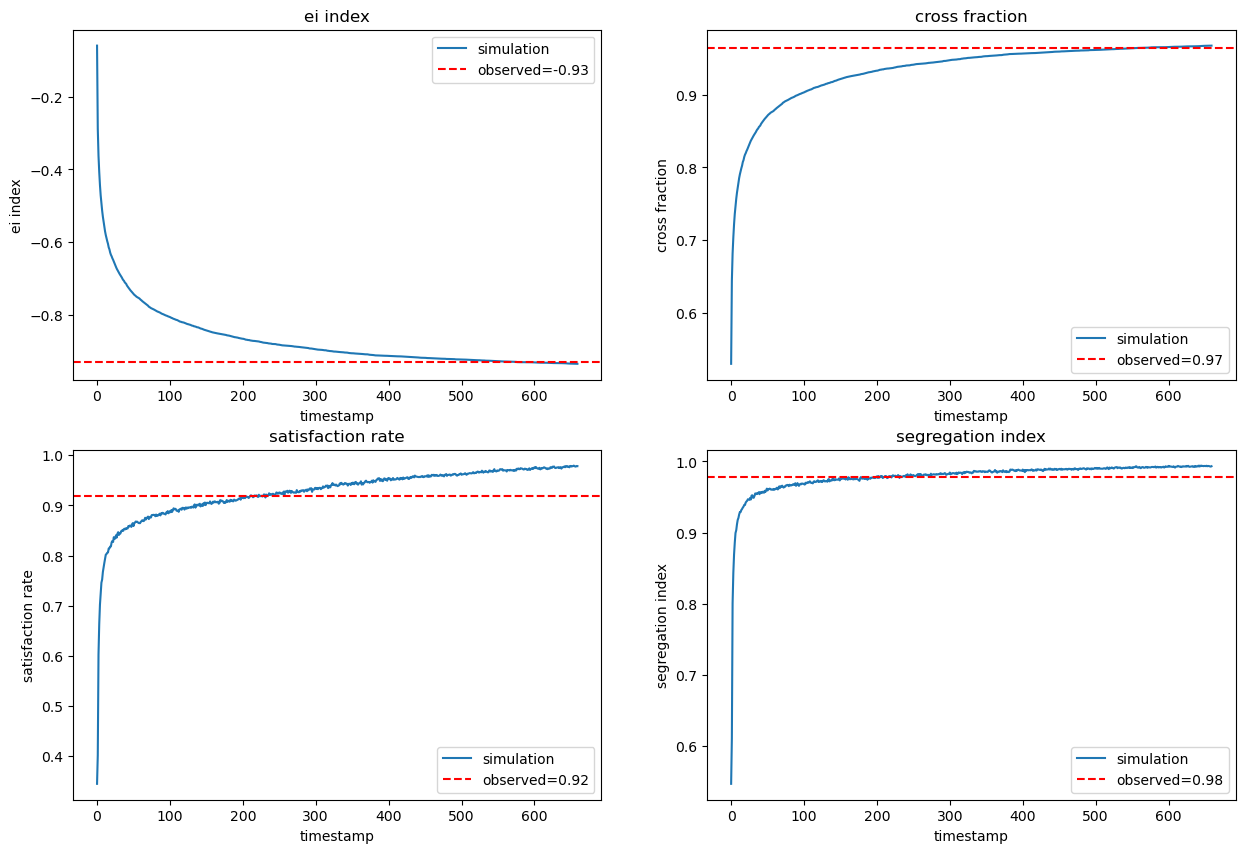

In [15]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

time_st = range(len(ei_index_sim))
simulation = [ei_index_sim, cross_fraction_sim, satisfaction_rate_sim, segregation_index_sim]
observed  = [ei_obs, cross_fraction_obs, satisfaction_rate_obs, segregation_index_obs]
titles = ['ei index', 'cross fraction', 'satisfaction rate', 'segregation index']

for ax, sim, obs, title in zip(axes.flat, simulation, observed, titles):
    ax.plot(time_st, sim, label='simulation')
    ax.set_xlabel('timestamp')
    ax.set_ylabel(title)
    ax.axhline(obs, color='red', linestyle='--', label=f'observed={obs:.2f}')
    ax.set_title(title)
    ax.legend()
    

In [16]:
dump = {
    'file': 'climate_23.graphml',
    'treshold': treshold,
    'ei_obs': ei_obs,
    'cross_fraction_obs': cross_fraction_obs,
    'satisfaction_rate_obs': satisfaction_rate_obs,
    'segregation_index_obs':segregation_index_obs,
    'ei_index_sim': ei_index_sim,
    'cross_fraction_sim': cross_fraction_sim,
    'satisfaction_rate_sim': satisfaction_rate_sim,
    'segregation_index_sim': segregation_index_sim
}
import json
json.dump(dump, open('dump_segregation_climate_23_95.json', 'w'))